# **Classification Model Training Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [1]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Mounted at /content/gdrive

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data
/content/gdrive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [3]:
# <Student to fill this section>


### 0.d Import Packages

In [4]:
# <Student to fill this section>
import pandas as pd
import altair as alt
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

---
## A. Project Description


In [5]:
# <Student to fill this section>
group_name = "Group 24"
student_name = "Yuyang Chen"
student_id = "13417454"

In [6]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [8]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [9]:
# <Student to fill this section>
business_use_case_description = """

The model aims to support the sales support team by identifying customers at high risk of churning in the next 3 months.

"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:
# <Student to fill this section>
business_objectives = """

Goal: Build a classification model to predict churn probability for each customer in the upcoming 3-month period.


"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
# <Student to fill this section>
stakeholders_expectations_explanations = """

Stakeholders:
-Telecom Customers: Requires better service from telecom with lower price, Ensure safety of privacy
-Telecom Company Managers: Requires higher customer adhesiveness
-Sales Team: Identify customers that are in higher risk to churn, Identify reasons why customers churn & ways to stop customers from churning
-Model Developers: Develop a model that satisfy the  above requirements


"""

In [14]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets

In [116]:
# <Student to fill this section>
try:
  df = pd.read_csv(folder_path / 'customer_satisfaction_clean.csv')
except Exception as e:
  print(e)

In [16]:
# <Student to fill this section>


In [17]:
# <Student to fill this section>


### C.2 Define Target variable

In [18]:
# <Student to fill this section>
target_definition_explanations = """

"Churned"

"""

In [19]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [20]:
# <Student to fill this section>

target_name = 'churned'

### C.4 Explore Target variable

In [21]:
#find empty cells in the column
df['churned'].isna().sum()

np.int64(0)

In [22]:
#nice there are none

In [23]:
#Count distinctive values in the column
df.value_counts(target_name)

,count
churned,
0,5174
1,1869


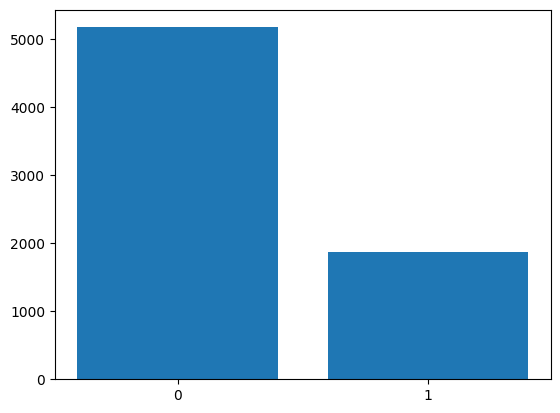

In [24]:
#Display histogram of target value, for visibility
x = np.array(["0", "1"])
y = np.array([5174, 1869])

plt.bar(x,y)
plt.show()

In [112]:
# <Student to fill this section>
target_distribution_explanations = """

The distribution of the target variable "churned" (customer churn) is as follows:
Total samples: 7,043
Non-churned customers (0): 5,174 (73.5% of total)
Churned customers (1): 1,869 (26.5% of total)


"""

In [113]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

###C.5 Null Hyphothesis

***There is no statistically significant difference in the predictive performance between the Random Forest and XGBoost algorithms on the given dataset.***

### C.6 Explore Feature of Interest 1

> You can add more cells in this section

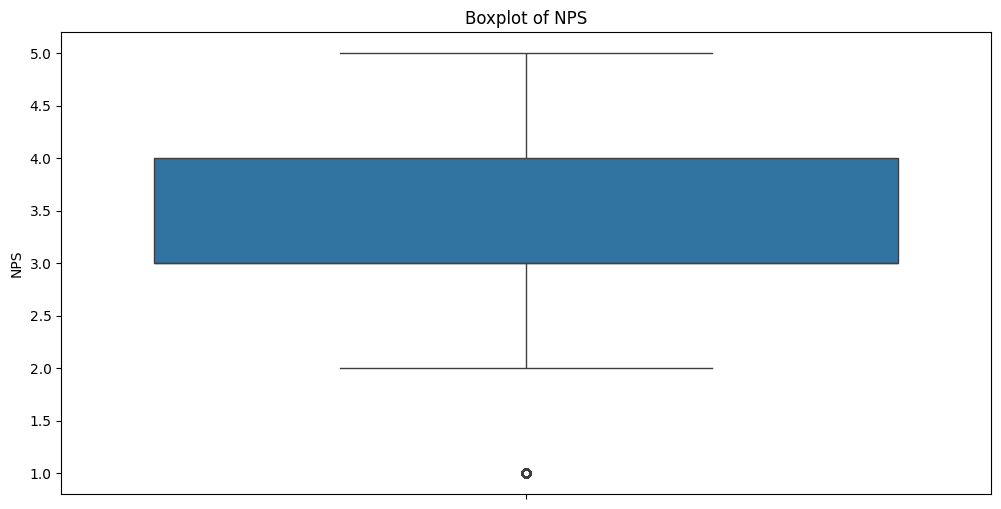

In [27]:

# Generate boxplots for NPS
plt.figure(figsize=(12, 6))
sns.boxplot(df['nps'])
plt.ylabel('NPS')
plt.title('Boxplot of NPS')
plt.show()

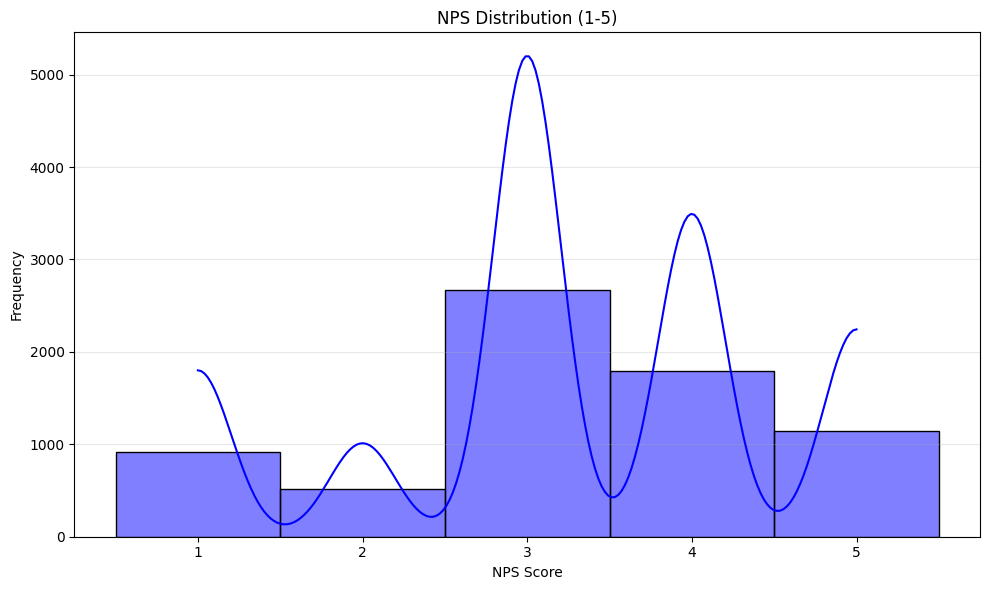

In [28]:
# NPS histogram
plt.figure(figsize=(10,6))
sns.histplot(df['nps'],
             bins=np.arange(0.5, 6.5, 1),
             kde=True,
             color='blue')
plt.xticks(range(1, 6))  #set int 1-5
plt.title('NPS Distribution (1-5)')
plt.xlabel('NPS Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# <Student to fill this section>
feature1_insights = """




"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='feature1_insights', value=feature1_insights)

### C.7 Explore Feature of Interest 2

> You can add more cells in this section

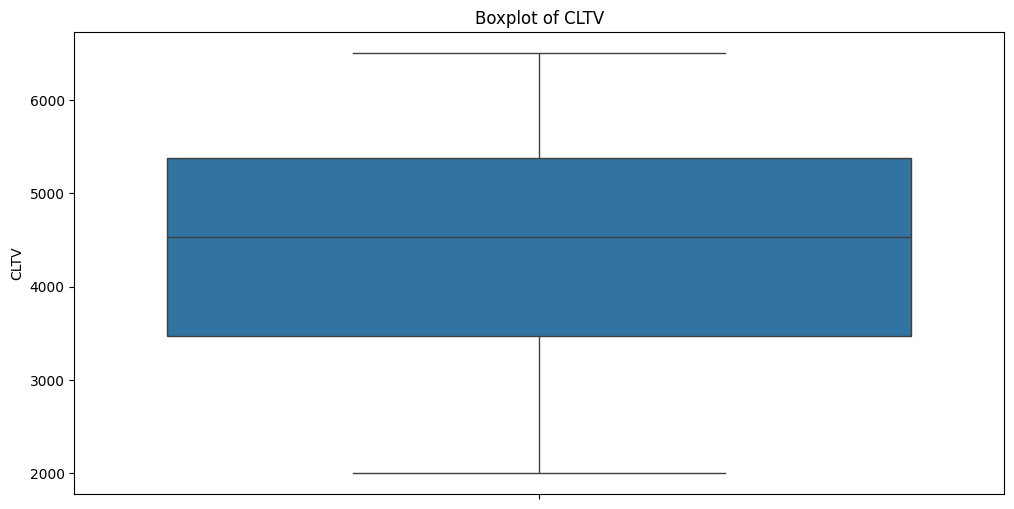

In [31]:
# Generate boxplots for cltv
plt.figure(figsize=(12, 6))
sns.boxplot(df['cltv'])
plt.ylabel('CLTV')
plt.title('Boxplot of CLTV')
plt.show()

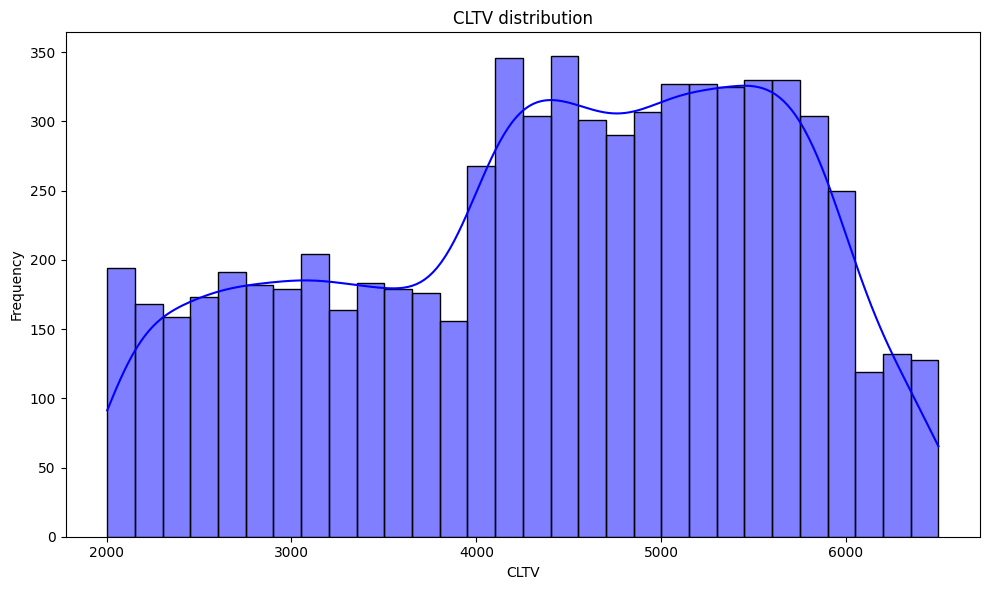

In [32]:
# cltv histogram
plt.figure(figsize=(10,6))
sns.histplot(df['cltv'], bins=30, kde=True, color='blue')
plt.title('CLTV distribution')
plt.xlabel('CLTV')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [33]:
# <Student to fill this section>
feature_2_insights = """
"""

In [34]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.8 Explore Feature of Interest n

> You can add more cells in this section

In [35]:
# <Student to fill this section>

In [36]:
# <Student to fill this section>
feature_n_insights = """
"""

In [37]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## D. Feature Selection


###D.1 Approach "Heatmap"

In [118]:
# feature encoding
encoder = sklearn.preprocessing.LabelEncoder()
df['reason'] = encoder.fit_transform(df['reason'])

In [119]:
#transform check
df.head()

,Unnamed: 0,customer_id,nps,cltv,reason,churned
0,0,70f18737-5835-4639-be44-f1a8c6604490,4,2056,20,0
1,1,206e8726-2743-4739-8f2f-758e30256314,3,2916,20,0
2,2,40da1c87-0650-4378-b8d7-0a49cb21085c,4,5248,20,0
3,3,4e28bb69-cee2-4fdf-8831-28935bb5e9b6,3,4607,20,0
4,4,39c9339b-c22b-4bf2-8c73-deb7b6e02de1,4,3030,20,0


In [40]:
#Calculate correlation
#reminder: explain corr() in report

correlation_matrix = df.corr(numeric_only=True)

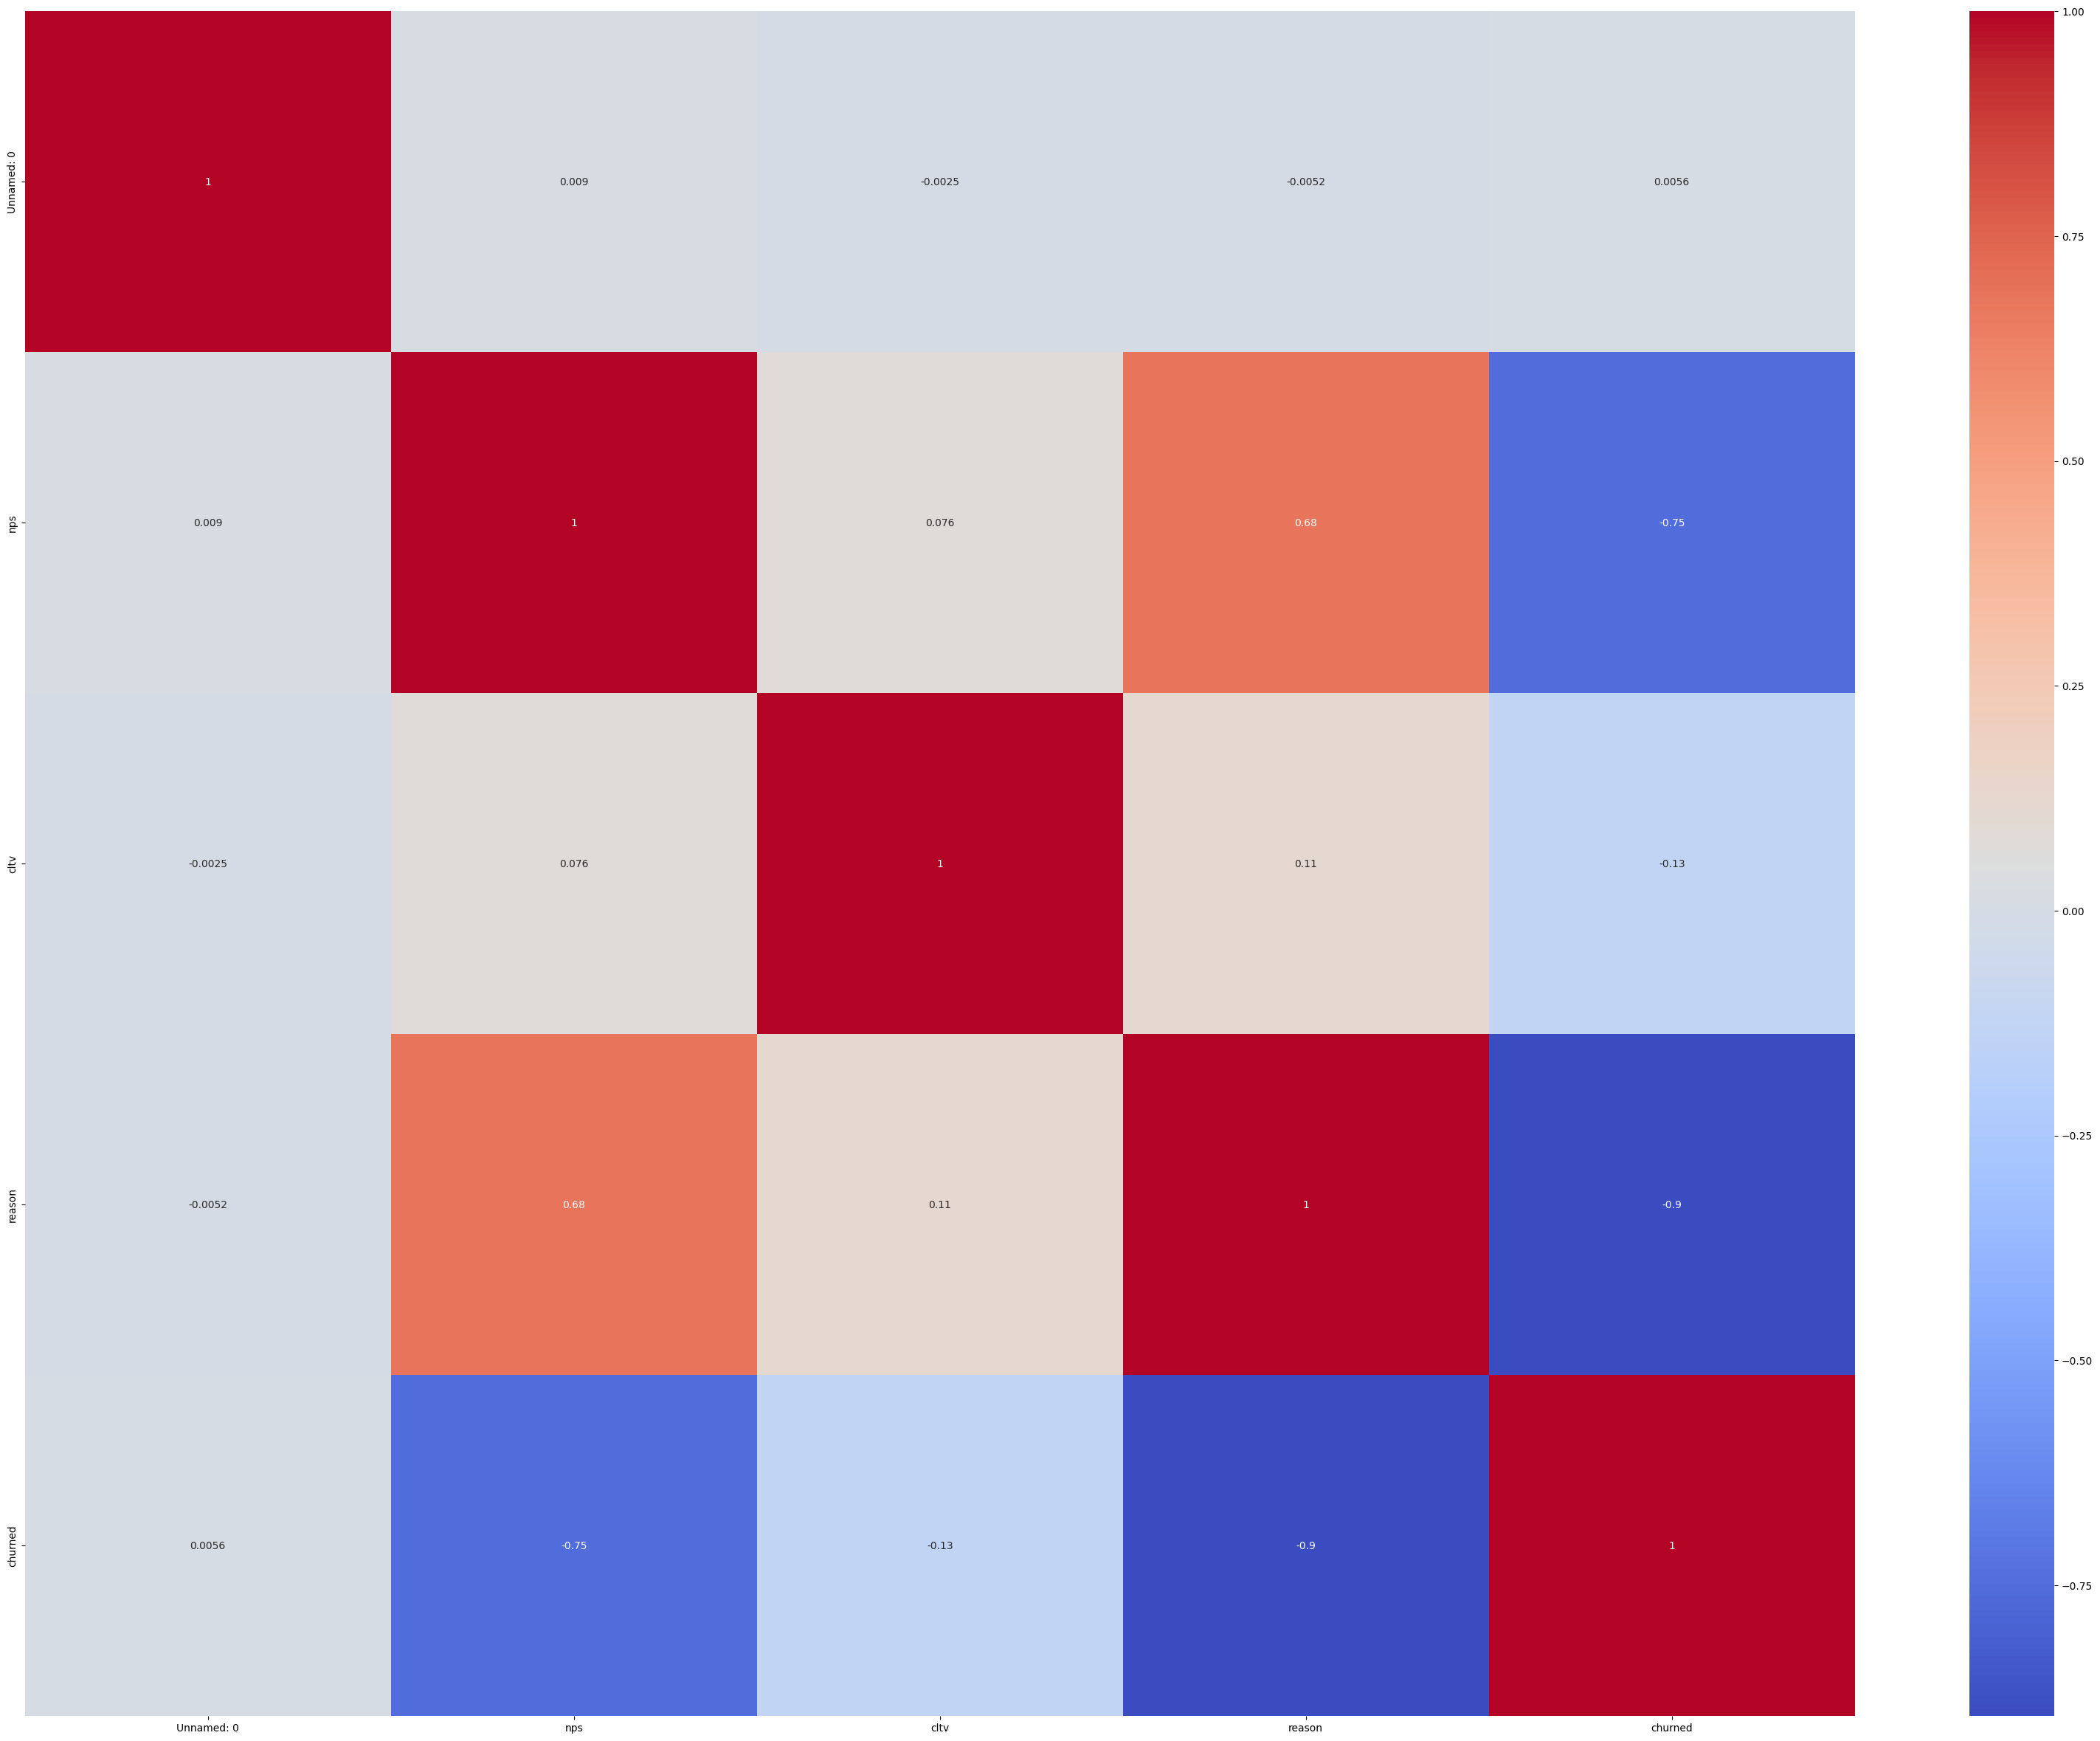

In [41]:
#visualise correlation with heatmap

plt.figure(figsize=(40, 30))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [42]:
# <Student to fill this section>

features_list = ['cltv', 'nps']

In [121]:
# <Student to fill this section>
feature_selection_insights = """

1.Correlation between reason & churned is -0.9, this signifies very high correlation between these two, therefore, it should be dropped to avoid overfitting.
2.CLTV has -0.17 correlation with churned, signifies that customer value has no significant relations with whether they will churn.
3.NPS has -0.75 correlation with churned, signifies that customer satisfaction has significant relations with whether they will churn.

"""

In [122]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_insights', value=feature_selection_insights)

---
## E. Data Preparation

### E.1 Data Transformation: Encode reasons

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts

In [45]:
# <Student to fill this section>
# feature encoding
# transformation done in previous section
# code as follows
#encoder = sklearn.preprocessing.LabelEncoder()
#df['reason'] = encoder.fit_transform(df['reason'])

In [123]:
# <Student to fill this section>
data_cleaning_1_explanations = """

Previous data was encoded for better data understanding, and made correlation analysis possible.

"""

In [124]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [48]:
# Drop irrelevant column
df = df.drop(columns=['customer_id'])

In [49]:
# Drop over correlated column
df = df.drop(columns=['reason'])

In [50]:
# <Student to fill this section>
data_cleaning_2_explanations = """
"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [52]:
# <Student to fill this section>

In [53]:
# <Student to fill this section>
data_cleaning_3_explanations = """
"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "Churned"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [55]:
#Feature engineering completed in EDA workbook
#Code as follows
# Create target variable (1 = churned, 0 = active)
#df_eng['churned'] = np.where(df_eng['reason'].notnull(), 1, 0)
#df_eng['churned'].value_counts()

In [127]:
# <Student to fill this section>
feature_engineering_1_explanations = """

target variable was created for a churn prediction model. It is essential for classification models.
It assumes that if the reason column (which likely records a customer's reason for leaving) is not null, then the customer has churned.

"""

In [128]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [58]:
# <Student to fill this section>
df['reason']

In [59]:
# <Student to fill this section>
feature_engineering_2_explanations = """
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [61]:
# <Student to fill this section>

In [62]:
# <Student to fill this section>
feature_engineering_3_explanations = """
"""

In [63]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

> Provide some explanations on what is the best strategy to use for data splitting for this dataset


In [64]:
#split dataset into feature and target
X = df.drop(columns=['churned'])
y = df['churned']

In [65]:
#count y
y.value_counts(normalize=True)

,proportion
churned,
0,0.73463
1,0.26537


In [66]:
#import data split
from sklearn.model_selection import train_test_split

In [67]:
# Split into training and temporary (validation + test) sets (80% train, 20% temp)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=8)

# Split the temporary set into validation and test sets (50% validation, 50% test of the 20% temp data, resulting in 10% each of the total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Training data size:", len(X_train))
print("Validation data size:", len(y_val))
print("Test data size:", len(y_test))

Training data size: 5634
Validation data size: 704
Test data size: 705


In [131]:
# <Student to fill this section>
data_splitting_explanations = """

Split into training and temporary (validation + test) sets (80% train, 20% temp), then Split the temporary set into validation and test sets (50% validation, 50% test of the 20% temp data, resulting in 10% each of the total). Seperate each data set prevents overfitting（Hastie et al., 2009）.

"""

In [132]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation: Change target names

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [129]:
#change target names for better interpretations
y_train.replace(['Active', 'Churned'], [0, 1], inplace=True)
y_val.replace(['Active', 'Churned'], [0, 1], inplace=True)
y_test.replace(['Active', 'Churned'], [0, 1], inplace=True)

In [130]:
y_train.value_counts(normalize=True)

,proportion
churned,
0,0.730742
1,0.269258


In [133]:
# <Student to fill this section>
data_transformation_1_explanations = """

To fix previous encoding for 'churned', to make classification models workable.

"""

In [134]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<put_name_here\>"

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [74]:
# <Student to fill this section>

In [75]:
# <Student to fill this section>
data_transformation_2_explanations = """
"""

In [76]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "\<put_name_here\>"

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [77]:
# <Student to fill this section>

In [78]:
# <Student to fill this section>
data_transformation_3_explanations = """
"""

In [79]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [135]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(folder_path / 'X_train.csv', index=False)
  y_train.to_csv(folder_path / 'y_train.csv', index=False)
except Exception as e:
  print(e)

In [136]:
# Do not modify this code
# Save training set
try:
  X_val.to_csv(folder_path / 'X_val.csv', index=False)
  y_val.to_csv(folder_path / 'y_val.csv', index=False)
except Exception as e:
  print(e)

In [137]:
# Do not modify this code
# Save training set
try:
  X_test.to_csv(folder_path / 'X_test.csv', index=False)
  y_test.to_csv(folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Assess Baseline Model

### I.1 Generate Predictions with Baseline Model

In [138]:
# import and fit RF model (baseline)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
# Instantiate the RF class into a variable called rf and fit it on the training set
rf = RandomForestClassifier(class_weight="balanced", random_state=42)

In [84]:
#set parameters grid for GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "criterion": ["gini", "entropy"]
}


In [85]:
#fit GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring="f1")
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

### I.2 Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [139]:
# <Student to fill this section>
from sklearn.metrics import classification_report

In [144]:
# <Student to fill this section>
performance_metrics_explanations = """

F1-Score selected to value model performance, since it is more useful in this condition, when classes are imbalanced (He & Garcia, 2009).
Same applies for Recall.
"""

In [145]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

### I.3 Baseline Model Performance

> Provide some explanations on model performance


In [89]:
# print best params
print("Best Parameters:", grid_search.best_params_)
print("Best F1-score:", np.round(grid_search.best_score_, 4))

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best F1-score: 0.8702


In [90]:
#print classification report, display recall
y_pred = grid_search.best_estimator_.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96       516
           1       1.00      0.77      0.87       189

    accuracy                           0.94       705
   macro avg       0.96      0.88      0.91       705
weighted avg       0.94      0.94      0.93       705



In [154]:
# <Student to fill this section>
baseline_performance_explanations = """

We received a f1-score of 0.8702, suggests a good predictive power suitable for business use, however there are room for improvements. Better parameters can be found, or we can use boosted tree-based algorithms.
"""

In [155]:
# Do not modify this code
print_tile(size="h3", key='baseline_performance_explanations', value=baseline_performance_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [93]:
# <Student to fill this section>
from xgboost import XGBClassifier

In [156]:
# <Student to fill this section>
algorithm_selection_explanations = """

Considering tree-based boosted algorithms is what we desire, that left us choices between AdaBoost and XGBoost. According to El Mehdi Ferrouhi & Ibrahim Bouabdallaoui(2024), XGBoost works better in large datasets, with benefits in speed.

"""

In [157]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [96]:
# <Student to fill this section>
param_grid = {
    "learning_rate": [0.01, 0.05],
    "n_estimators": [500, 1000],
    "max_depth": [3, 5, 7],
    "scale_pos_weight": [2.5, 2.7, 3.0],
}

In [97]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
"""

In [98]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [99]:
# load xgb
xgb = XGBClassifier(objective="binary:logistic", n_jobs=-1, random_state=42)

In [100]:
#fit model
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring="f1", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05], 'max_depth': [3, 5, 7],
                         'n_estimators': [500, 1000],
                         'scale_pos_weight': [2.5, 2.7, 3.0]},
             scoring='f1')

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [101]:
# <Student to fill this section>
print("Best Parameters:", grid_search.best_params_)
print("Best F1-score:", np.round(grid_search.best_score_, 4))

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'scale_pos_weight': 2.5}
Best F1-score: 0.8686


In [102]:
#print classification report
from sklearn.metrics import classification_report
y_pred = grid_search.best_estimator_.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96       516
           1       1.00      0.77      0.87       189

    accuracy                           0.94       705
   macro avg       0.96      0.88      0.91       705
weighted avg       0.94      0.94      0.93       705



In [150]:
# <Student to fill this section>
model_performance_explanations = """

We received a f1-score of 0.8686, suggests a good predictive power suitable for business use, however, it is not better than RandomForest. Even though it is not as high as 0.906 in previous cases(Boozary et al., 2025), however, since this signifies model can distinguish 87% of churning customers, we believe this is acceptable.

"""

In [151]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [105]:
# <Student to fill this section>

In [160]:
# <Student to fill this section>
business_impacts_explanations = """

We received a f1-score of 0.8702, suggests a good predictive power suitable for business use, even though it is not as high as 0.906 in previous cases(Boozary et al., 2025), however, since this signifies model can distinguish 87% of churning customers, we believe this is acceptable, with room for further development.
Apart from that, since RandomForest has a lower cost of deployment than XGBoost, we consider applying a model using RandomForest can satisfy the business requirements.

"""

In [161]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [158]:
# <Student to fill this section>
experiment_outcome = "'Hypothesis Confirmed'"

In [159]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [162]:
# <Student to fill this section>
experiment_results_explanations = """

Comparing both F1-scores and recall scores, XGBoost did not perform better than RandomForest.

"""

In [163]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)